
# Lab 6: FEM 1D

### Exercise 1: Use FEM 1D to solve the EDO

Use FEM to solve the next EDO (improve the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
-\dfrac{d^2y}{dx^2}=xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(x-2)-x
\end{equation}

De manera "rudimentaria",

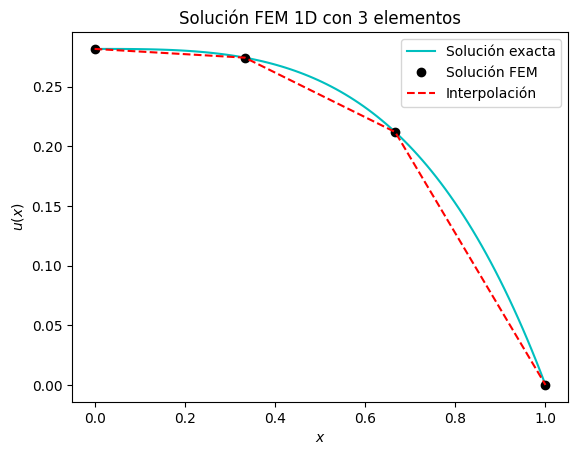

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate

def lin1(x,x1,x2): 
    return (x-x1)/(x2-x1)

def lin2(x,x1,x2):
    return (x2-x)/(x2-x1)

def fcarga(x):
    return x*np.exp(x)

def exact(x):
    e=np.exp(1)
    return np.exp(x)*(2-x)-x+1-e

def resolver_fem(N):
    h=1.0/N
    xi=np.linspace(0,1,N+1)
    A=np.zeros((N+1,N+1))
    b=np.zeros(N+1)

    for i in range(N):
        A[i,i]+=1/h
        A[i,i+1]+=-1/h
        A[i+1,i]+=-1/h
        A[i+1,i+1]+=1/h

    for i in range(1,N+1):
        x_min,x_max=xi[i-1],xi[i]
        int1=integrate.quad(lambda x: fcarga(x)*lin1(x,x_min,x_max),x_min,x_max)[0]
        int2=integrate.quad(lambda x: fcarga(x)*lin2(x,x_min,x_max),x_min,x_max)[0]
        b[i-1]+=int2
        b[i]+=int1

    Ua=3-np.exp(1)
    Ub=0

    for i in range(1,N):
        b[i]=b[i]-Ua*A[i,0]
        b[i]=b[i]-Ub*A[i,N]

    b[0]=Ua
    b[N]=Ub

    A[0,:]=0
    A[:,0]=0
    A[0,0]=1
    A[N,:]=0
    A[:,N]=0
    A[N,N]=1

    sol = np.linalg.solve(A, b)

    return xi, sol

N=3

xi,sol=resolver_fem(N)

x_new=np.linspace(0,1,100)
y_new=np.interp(x_new,xi,sol)

y_exact=exact(x_new)

plt.plot(x_new,y_exact,'c-',label='Solución exacta')
plt.plot(xi,sol,'ko',label=f'Solución FEM')
plt.plot(x_new,y_new,'r--',label='Interpolación')
plt.title(f'Solución FEM 1D con {N} elementos')
plt.xlabel('$x$')
plt.ylabel('$u(x)$')
plt.legend()
plt.show()

Vectorizando el código,

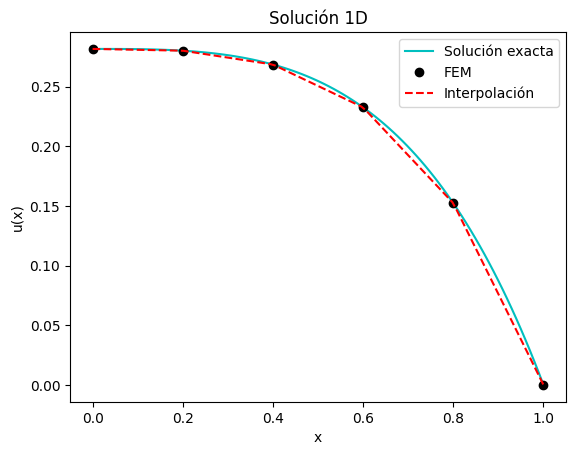

In [13]:
def solve_fem_1d(a,b,N,ua,ub,fcarga):
    h=(b-a)/N
    xi=np.linspace(a,b,N+1)
    
    A=np.zeros((N+1,N+1))
    b_vec=np.zeros(N+1)
    
    for i in range(N):
        x1,x2=xi[i],xi[i+1]
        
        N1=lambda x:(x2-x)/(x2-x1)
        N2=lambda x:(x-x1)/(x2-x1)
        
        A[i,i]+=1/h
        A[i,i+1]+=-1/h
        A[i+1,i]+=-1/h
        A[i+1,i+1]+=1/h
        
        int1=integrate.quad(lambda x:fcarga(x)*N1(x),x1,x2)[0]
        int2=integrate.quad(lambda x:fcarga(x)*N2(x),x1,x2)[0]
        
        b_vec[i]+=int1
        b_vec[i+1]+=int2

    for i in range(1,N):
        b_vec[i]=b_vec[i]-ua*A[i,0]
        b_vec[i]=b_vec[i]-ub*A[i,N]
        
    b_vec[0]=ua
    b_vec[N]=ub
    
    A[0,:]=0;A[:,0]=0;A[0,0]=1
    A[N,:]=0;A[:,N]=0;A[N,N]=1
    
    sol=np.linalg.solve(A,b_vec)
    
    return xi,sol

a=0
b=1
ua=3-np.exp(1)
ub=0

def f(x):
    return x*np.exp(x)
    
N_elements=5
x_fem,y_fem=solve_fem_1d(a,b,N_elements,ua,ub,f)

x_interp=np.linspace(a,b,100)
y_interp=np.interp(x_interp,x_fem,y_fem)

y_exact=exact(x_new)

plt.plot(x_new,y_exact,'c-',label='Solución exacta')
plt.plot(x_fem,y_fem,'ko',label=f'FEM')
plt.plot(x_interp,y_interp,'r--',label='Interpolación')
plt.title('Solución 1D')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.show()